In [1]:
import kagglehub

c:\Users\smako\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("sachinpatel21/az-handwritten-alphabets-in-csv-format")

print("Path to dataset files:", path)

100%|██████████| 185M/185M [00:21<00:00, 9.03MB/s] 

Extracting files...


Path to dataset files: C:\Users\smako\.cache\kagglehub\datasets\sachinpatel21\az-handwritten-alphabets-in-csv-format\versions\5


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('A_Z_Handwritten_Data.csv')

X = df.drop('0', axis=1).values / 255.0
y = df['0'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(26, activation='softmax') # 26 літер алфавіту
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

c:\Users\smako\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9284 - loss: 0.2563 - val_accuracy: 0.9560 - val_loss: 0.1520
Epoch 2/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9660 - loss: 0.1181 - val_accuracy: 0.9672 - val_loss: 0.1163
Epoch 3/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9733 - loss: 0.0913 - val_accuracy: 0.9700 - val_loss: 0.1055
Epoch 4/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9776 - loss: 0.0754 - val_accuracy: 0.9750 - val_loss: 0.0915
Epoch 5/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9802 - loss: 0.0661 - val_accuracy: 0.9761 - val_loss: 0.0864
Epoch 6/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9822 - loss: 0.0584 - val_accuracy: 0.9770 - val_loss: 0.0840
Epoch 7/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9839 - loss: 0.0523 - val_accuracy: 0.9780 - val_loss: 0.0840
Epoch 8/10
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9852 - loss: 0

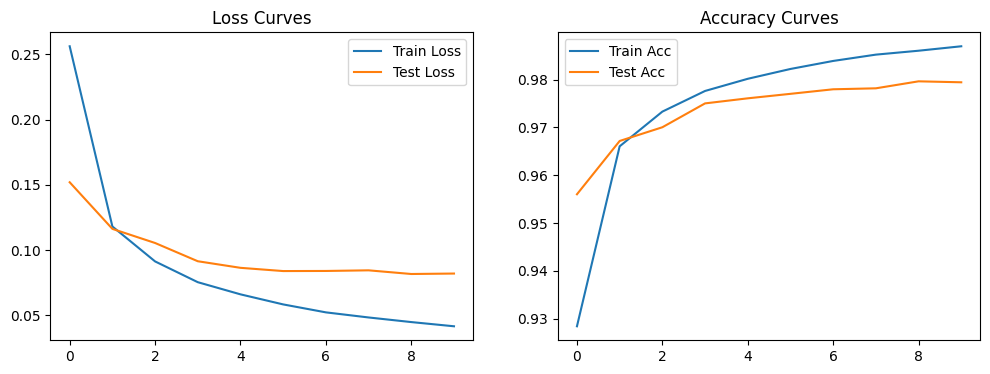

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Test Acc')
plt.legend()
plt.title('Accuracy Curves')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


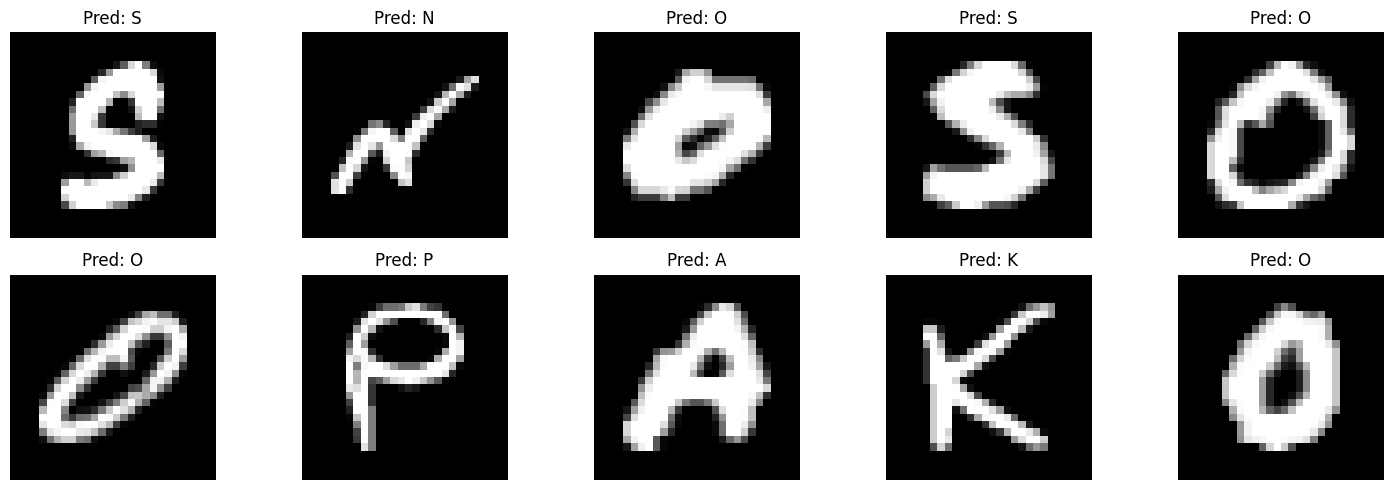

In [8]:
indices = np.random.choice(len(X_test), 10, replace=False)
predictions = np.argmax(model.predict(X_test[indices]), axis=1)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {chr(predictions[i] + 65)}") # Перетворення індексу в літеру
    plt.axis('off')
plt.tight_layout()
plt.show()